# 📊 End-to-End Data Pipeline: Market Price Benchmarking Dashboard

## Deskripsi Keseluruhan
Notebook ini mengimplementasikan **pipeline data terlengkap** untuk mengintegrasikan data pengeluaran transaksi pengguna dengan database acuan pasar (*market price benchmark*). Pipeline ini mencakup **8 tahapan utama** yang runtut dan saling terintegrasi:

1. **Data Collection** → Load dan inisialisasi dataset
2. **Data Cleaning/Preprocessing** → Sterilisasi teks, hapus duplikat
3. **Data Integration** → Merge multi-source dengan UPDATE & APPEND logic
4. **Data Transformation** → Normalisasi format, mapping kategori & item
5. **Data Validation (EDA)** → Gap analysis, quality control, visualisasi
6. **Feature Engineering** → Hitung fitur bisnis (price_difference, price_status)
7. **Feature Selection** → Pilih kolom esensial untuk production
8. **Final Export** → Output ke main_dashboard_dataset.csv

## Output yang Dihasilkan
`market_benchmark_cleaned.csv` - Dataset benchmark yang sudah diproses (305 items)

---


## 📗 DATA DICTIONARY (KAMUS DATA ACUAN PASAR)

### Dataset 1: market_benchmark_dataset.csv (Input - 2250 baris)
Database awal komoditas ritel Indonesia dengan struktur:

| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `item_name` | String | Nama barang komoditas (misal: Netflix, Gofood, Bensin, etc) |
| `item_category` | String | Kategori: Hiburan, Makanan & Minuman, Transportasi, Belanja, Tagihan |
| `avg_price` | Float | Rata-rata harga pasar (IDR) |
| `lower_bound` | Float | Harga minimum yang masih dianggap rasional |
| `upper_bound` | Float | Harga maksimum sebelum dianggap overpriced |

### Dataset 2: public_transactions_test_fixed.csv (Input - 1220 baris)
Riwayat transaksi pengguna dengan struktur:

| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `transaction_name` | String | Nama transaksi raw dari bank/aplikasi (misal: "G0F00D TR4NK", "netflix charge") |
| `category` | String | Kategori transaksi dari pengguna |
| `amount` | Float | Nominal transaksi (IDR) |
| `date` | Date | Tanggal transaksi |

### Dataset 3: sumber - Sheet1.csv (Input - 59 baris)
Data lapangan eksternal untuk update benchmark:

| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `Item` | String | Nama item dari riset lapangan |
| `Rata-rata (Rp)` | Float | Harga rata-rata dari lapangan |
| `Termurah (Rp)` | Float | Harga minimum dari lapangan |
| `Termahal (Rp)` | Float | Harga maksimum dari lapangan |

### Output Dataset: main_dashboard_dataset.csv (Final Production)

| Kolom | Tipe | Deskripsi | Source |
|-------|------|-----------|--------|
| `transaction_id` | Int | ID unik transaksi | df_trans |
| `date` | Date | Tanggal transaksi | df_trans |
| `transaction_name_clean` | String | Nama transaksi yang sudah dinormalisasi | Feature Engineering |
| `category` | String | Kategori komoditas | df_trans |
| `amount` | Float | Nominal pengeluaran | df_trans |
| `item_category_x` | String | Kategori dari benchmark | df_bench_cleaned |
| `avg_price` | Float | Harga rata-rata pasar | df_bench_cleaned |
| `lower_bound` | Float | Batas bawah harga wajar | df_bench_cleaned |
| `upper_bound` | Float | Batas atas harga wajar | df_bench_cleaned |
| `price_margin` | Float | Lebar rentang harga | Feature Engineering |
| `price_difference` | Float | Selisih pengeluaran vs rata-rata pasar | Feature Engineering |
| `price_status` | String | Status penilaian (Hemat/Normal/Ekstrem/No Data) | Feature Engineering |
| `price_percentage_of_avg` | Float | Persentase harga terhadap rata-rata | Feature Engineering |

---


## 🎯 PERTANYAAN BISNIS (SMART CRITERIA)

### Pertanyaan Utama:
**"Berapa nilai rata-rata rentang margin toleransi (selisih antara batas atas dan batas bawah harga pasar) pada masing-masing komoditas untuk memastikan indikator penilaian harga di dashboard bersifat objektif?"**

### Breakdown SMART Kriteria:
- **Specific (S):** Menghitung jarak rentang harga acuan (`upper_bound - lower_bound`) per komoditas
- **Measurable (M):** Diukur dengan operasi aritmatika & fungsi statistik deskriptif
- **Achievable (A):** Dapat dihitung langsung dari dataset yang lengkap
- **Relevant (R):** Memvalidasi batas harga tidak terlalu longgar atau terlalu ketat
- **Time-bound (T):** Selesai sebelum export ke production dashboard

---


## ⏱️ TAHAP 1: DATA COLLECTION
### Inisialisasi & Load Dataset dari Multiple Sources

Pada tahap ini kita:
1. Mengamankan jalur akses file menggunakan `pathlib.Path`
2. Memuat 3 dataset utama dengan error handling
3. Mencetak dimensi awal untuk validasi



In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. SETUP: Amankan Jalur Akses File
# ============================================
base_dir = Path('.').resolve()
print(f"📂 Working Directory: {base_dir}")

# Definisikan path ke semua file input
file_bench = base_dir / 'market_benchmark_dataset.csv'
file_trans = base_dir / 'public_transactions_test_fixed.csv'
file_source_path = base_dir / 'sumber - Sheet1.csv'

# ============================================
# 2. LOAD DATASET DENGAN ERROR HANDLING
# ============================================
print("\n📥 Loading Datasets...")

# Load Dataset 1: Benchmark Awal
try:
    df_bench = pd.read_csv(file_bench, engine='python')
    print(f"✓ Dataset 1 (Benchmark): {df_bench.shape[0]} baris × {df_bench.shape[1]} kolom")
except Exception as e:
    print(f"✗ Error loading benchmark: {e}")
    df_bench = pd.DataFrame()

# Load Dataset 2: Transaksi Publik
try:
    df_trans = pd.read_csv(file_trans, engine='python')
    print(f"✓ Dataset 2 (Transaksi): {df_trans.shape[0]} baris × {df_trans.shape[1]} kolom")
except Exception as e:
    print(f"✗ Error loading transactions: {e}")
    df_trans = pd.DataFrame()

# Load Dataset 3: Data Lapangan (dengan fallback separator)
try:
    try:
        df_source = pd.read_csv(file_source_path, sep=';', encoding='utf-8-sig', engine='python')
        df_source.columns = df_source.columns.str.strip()
        if 'Item' not in df_source.columns:
            raise ValueError("Kolom 'Item' tidak ditemukan")
    except:
        df_source = pd.read_csv(file_source_path, sep=',', encoding='utf-8-sig', engine='python')
        df_source.columns = df_source.columns.str.strip()
    
    print(f"✓ Dataset 3 (Lapangan): {df_source.shape[0]} baris × {df_source.shape[1]} kolom")
except Exception as e:
    print(f"✗ Error loading source: {e}")
    df_source = pd.DataFrame()

# ============================================
# 3. CETAK PREVIEW DATA
# ============================================
print("\n" + "="*70)
print("PREVIEW DATASET 1: BENCHMARK AWAL (5 baris pertama)")
print("="*70)
print(df_bench.head())
print(f"\nInfo Kolom: {df_bench.columns.tolist()}")

print("\n" + "="*70)
print("PREVIEW DATASET 2: TRANSAKSI PUBLIK (5 baris pertama)")
print("="*70)
print(df_trans.head())
print(f"\nInfo Kolom: {df_trans.columns.tolist()}")

print("\n" + "="*70)
print("PREVIEW DATASET 3: DATA LAPANGAN (5 baris pertama)")
print("="*70)
print(df_source.head())
print(f"\nInfo Kolom: {df_source.columns.tolist()}")

print("\n✓ TAHAP 1 SELESAI: Data Collection")


📂 Working Directory: G:\Semester4\capstone-project

📥 Loading Datasets...
✓ Dataset 1 (Benchmark): 2250 baris × 5 kolom
✓ Dataset 2 (Transaksi): 1220 baris × 4 kolom
✓ Dataset 3 (Lapangan): 59 baris × 5 kolom

PREVIEW DATASET 1: BENCHMARK AWAL (5 baris pertama)
       item_category            item_name  avg_price  lower_bound  upper_bound
0            Tagihan  Listrik PLN Bulanan     214375       161854       250167
1            Tagihan  Listrik PLN Bulanan     263252       231250       296443
2            Belanja           Buku Tulis       6012         4471         7524
3  Makanan & Minuman               Es Teh       4548         3774         5746
4          Transport         Parkir Motor       3080         2654         3394

Info Kolom: ['item_category', 'item_name', 'avg_price', 'lower_bound', 'upper_bound']

PREVIEW DATASET 2: TRANSAKSI PUBLIK (5 baris pertama)
                transaction_name    amount category  category_encoded
0       TIKET BIOSKOP XXI - <ID>  284160.0  Hiburan 

## ⏱️ TAHAP 2: DATA CLEANING & PREPROCESSING
### Sterilisasi Teks, Normalisasi Format, Hapus Duplikat

Langkah-langkah yang dilakukan:
1. **Text Normalization**: Standardisasi format penulisan (trim, title case)
2. **Duplicate Removal**: Hapus entri dengan format leet-speak atau rusak
3. **Keyword Mapping**: Terapkan kamus penerjemah untuk text yang bervariasi
4. **Category Standardization**: Seragamkan kategori di semua dataset



In [2]:
# ============================================
# 1. NORMALISASI TEKS DASAR - DATASET BENCHMARK
# ============================================
print("🔄 Tahap 2a: Text Normalization pada Dataset Benchmark...")

# Trim dan convert ke Title Case
df_bench['item_category'] = df_bench['item_category'].str.strip().str.title()
df_bench['item_name'] = df_bench['item_name'].str.strip().str.title()

print(f"✓ Normalisasi selesai: {df_bench.shape[0]} baris")

# ============================================
# 2. HAPUS ENTRI DUPLIKAT DENGAN LEET-SPEAK
# ============================================
print("\n🔄 Tahap 2b: Menghapus duplikat leet-speak...")

leet_items_to_remove = [
    'N3Tfl1X', 'Sp0T1Fy', 'D1Sn3Y H0Tst4R', 'G0F00D Tr4Ns4Ks1', 'K0P1 K3N4Ng4N C4F3',
    'M13 G4C04N R3St', 'Gr4Bf00D M3M0', 'Gr0c3Ry 1Nd0M4R3T', 'M4K4N D1 R3St0R4N',
    'T0K0P3D14', 'Sh0P33P4Y', 'B3L4Nj4 F4Sh10N', 'B3L4Nj4 3L3Ktr0N1K', '1K34',
    '1S1 B3Ns1N P3Rt4M1N4', 'G0P4Y G0R1D3', 'B00K1Ng H0T3L Tr4V3L0K4', 'Gr4B R1D3 0V0',
    'T1K3T P3S4W4T', 'T1K3T K3R3T4 K41', 'Drv Grab Ride Ovo', 'Dbt Grab Ride Ovo', 'Mbca Grab Ride Ovo'
]

baris_sebelum = len(df_bench)
df_bench = df_bench[~df_bench['item_name'].isin(leet_items_to_remove)]
baris_dihapus = baris_sebelum - len(df_bench)

print(f"✓ {baris_dihapus} baris duplikat dihapus | Sisa: {len(df_bench)} baris")

# ============================================
# 3. PERBAIKI KATEGORI - Arah 'Lainnya' ke 'Transportasi'
# ============================================
print("\n🔄 Tahap 2c: Standardisasi kategori...")

df_bench['item_category'] = df_bench['item_category'].replace('Lainnya', 'Transportasi')

print("Kategori setelah standardisasi:")
print(df_bench['item_category'].value_counts())

# ============================================
# 4. BUAT KAMUS KEYWORD MAPPING (Extraction Function)
# ============================================
print("\n🔄 Tahap 2d: Membangun Keyword Extraction Function...")

def extract_keyword(raw_name):
    """
    Menerjemahkan variasi teks transaksi mentah menjadi nama komoditas baku.
    Menggunakan pendekatan 'first match' untuk efisiensi.
    """
    raw_name = str(raw_name).lower()
    
    # Kamus canonical keyword mapping
    keywords = {
        # === HIBURAN ===
        'bioskop': 'Tiket Bioskop', 'spotify': 'Spotify Premium', 'sp0t1fy': 'Spotify Premium',
        'netflix': 'Netflix', 'n3tfl1x': 'Netflix', 'nf': 'Netflix', 'netf': 'Netflix',
        'disney': 'Disney Hotstar', 'd1sn3y': 'Disney Hotstar', 'hotstar': 'Disney Hotstar',
        'disney+': 'Disney Hotstar', 'd1sn3y h0tst4r': 'Disney Hotstar', 'youtube': 'Langganan Youtube Premium',
        'yt premium': 'Langganan Youtube Premium', 'canva': 'Canva Pro Sharing',
        'chatgpt': 'Langganan Chatgpt Plus Patungan', 'chat gpt': 'Langganan Chatgpt Plus Patungan',
        'gym': 'Gym Harian Mahasiswa', 'karaoke': 'Karaoke 1 Jam', 'futsal': 'Sewa Lapangan Futsal',
        'badminton': 'Sewa Lapangan Badminton', 'biliar': 'Main Biliar 1 Jam', 'bowling': 'Main Bowling 1 Game',
        'photobox': 'Photobox Studio', 'steam': 'Topup Saldo Steam Wallet', 'valorant': 'Topup Valorant Points',
        'mobile legends': 'Topup Diamond Mobile Legends', 'ml diamond': 'Topup Diamond Mobile Legends',
        
        # === TAGIHAN ===
        'pdam': 'Air Pdam Bulanan', 'pln': 'Listrik Pln Bulanan', 'listrik': 'Listrik Pln Bulanan',
        'token listrik': 'Token Listrik Kosan 50Rb', 'indihome': 'Wifi Indihome Bulanan', 'wifi': 'Wifi Indihome Bulanan',
        'bpjs': 'Bpjs Kesehatan Kelas 2', 'gopaylater': 'Cicilan Gopaylater', 'spaylater': 'Cicilan Spaylater',
        'kredivo': 'Tagihan Kredivo', 'kartu kredit': 'Tagihan Kartu Kredit', 'laundry': 'Laundry Kiloan Pakaian Reguler',
        'pulsa telkomsel': 'Pulsa', 'pulsa': 'Pulsa',
        
        # === BELANJA ===
        'belanja elektronik': 'Belanja Elektronik', 'b3l4nj4 3l3ktr0n1k': 'Belanja Elektronik',
        'belanja fashion': 'Belanja Fashion', 'b3l4nj4 f4sh10n': 'Belanja Fashion', 'ikea': 'Ikea', '1k34': 'Ikea',
        'tokopedia': 'Tokopedia', 't0k0p3d14': 'Tokopedia', 'tokped': 'Tokopedia', 'shopee': 'Shopee', 'sh0p33': 'Shopee',
        'shopeepay': 'Topup Shopeepay', 'sh0p33p4y': 'Topup Shopeepay', 'gopay': 'Topup Gopay', 'g0p4y': 'Topup Gopay',
        'ovo': 'Topup Ovo', 'dana': 'Topup Saldo Dana', 'linkaja': 'Topup Saldo Linkaja', 'flazz': 'Topup Saldo Flazz E-Money',
        'vitamin': 'Vitamin C', 'paracetamol': 'Paracetamol', 'masker': 'Masker Medis', 'hand sanitizer': 'Hand Sanitizer',
        
        # === MAKANAN & MINUMAN ===
        'grabfood': 'Grabfood', 'gr4bf00d': 'Grabfood', 'gr4bf00d m3m0': 'Grabfood', 'gofood': 'Gofood',
        'go-food': 'Gofood', 'go food': 'Gofood', 'g0f00d': 'Gofood', 'g0f00d tr4ns4ks1': 'Gofood',
        'kopi kenangan': 'Kopi Kenangan', 'k0p1 k3n4ng4n': 'Kopi Kenangan', 'kenangan': 'Kopi Kenangan',
        'mie gacoan': 'Mie Gacoan', 'm13 g4c04n': 'Mie Gacoan', 'gacoan': 'Mie Gacoan', 'indomaret': 'Grocery Indomaret',
        '1nd0m4r3t': 'Grocery Indomaret', 'gr0c3ry 1nd0m4r3t': 'Grocery Indomaret', 'alfamart': 'Grocery Indomaret',
        'mcdonalds': 'Mcdonalds', 'mcd': 'Mcdonalds', 'mc donalds': 'Mcdonalds', 'makan di restoran': 'Makan Di Restoran',
        'm4k4n d1 r3st0r4n': 'Makan Di Restoran', 'solaria': 'Makan Di Restoran', 'kfc': 'Makan Di Restoran',
        'resto': 'Makan Di Restoran', 'warteg': 'Nasi Rames Warteg', 'burjo': 'Nasi Telor Dadar Burjo',
        'bakso': 'Bakso', 'mie ayam': 'Mie Ayam', 'nasi goreng': 'Nasi Goreng', 'ayam geprek': 'Ayam Geprek',
        'nasi padang': 'Nasi Padang', 'boba': 'Boba Drink', 'es teh': 'Es Teh', 'kopi susu': 'Kopi Susu Gula Aren',
        'matcha': 'Matcha Latte', 'martabak': 'Martabak Manis',
        
        # === TRANSPORTASI ===
        'goride': 'Go-Ride', 'go-ride': 'Go-Ride', 'go ride': 'Go-Ride', 'g0-r1d3': 'Go-Ride',
        'grabbike': 'Grabbike', 'grab bike': 'Grabbike', 'grab ride': 'Grabbike', 'gr4b r1d3': 'Grabbike',
        'gocar': 'Gocar Trip Pendek', 'go-car': 'Gocar Trip Pendek', 'go car': 'Gocar Trip Pendek',
        'grabcar': 'Grabcar Trip Pendek', 'grab car': 'Grabcar Trip Pendek', 'maxim': 'Maxim Motor Reguler',
        'indriver': 'Indriver Mobil', 'traveloka': 'Destinasi Traveloka', 'tr4v3l0k4': 'Destinasi Traveloka',
        'b00k1ng h0t3l': 'Booking Hotel Traveloka', 'booking hotel': 'Booking Hotel Traveloka',
        'tiket pesawat': 'Tiket Pesawat', 'p3s4w4t': 'Tiket Pesawat', 't1k3t p3s4w4t': 'Tiket Pesawat',
        'kereta': 'Tiket Kereta Lokal', 'k3r3t4': 'Tiket Kereta Lokal', 't1k3t k3r3t4': 'Tiket Kereta Lokal',
        'krl': 'Tiket Krl Commuter Line', 'mrt': 'Tiket Mrt Reguler', 'lrt': 'Tiket Lrt Reguler',
        'transjakarta': 'Tiket Transjakarta', 'damri': 'Tiket Bus Damri', 'bus damri': 'Tiket Bus Damri',
        'bus akap': 'Tiket Bus Akap', 'shuttle': 'Shuttle Travel Luar Kota', 'bensin': 'Bensin Pertalite 1 Liter',
        'b3ns1n': 'Bensin Pertalite 1 Liter', 'pertamina': 'Bensin Pertalite 1 Liter', 'pertalite': 'Bensin Pertalite 1 Liter',
        'pertamax': 'Bensin Pertamax 1 Liter', 'shell': 'Bensin Shell Super 1L', 'spbu': 'Bensin Pertalite 1 Liter',
        'parkir': 'Parkir Motor', 'tambal ban': 'Tambal Ban Motor Bocor', 'ganti oli': 'Ganti Oli Motor',
        'cuci motor': 'Cuci Motor Cepat', 'servis motor': 'Servis Rutin Motor'
    }
    
    # Cari keyword yang cocok (first match strategy)
    for key, clean_name in keywords.items():
        if key in raw_name:
            return clean_name
    
    # Jika tidak cocok, return title case dari raw name
    return str(raw_name).strip().title()

# Terapkan ke dataset transaksi
df_trans['transaction_name_clean'] = df_trans['transaction_name'].apply(extract_keyword)

print("\n✓ Keyword extraction function diterapkan")
print(f"✓ Contoh mapping:")
print(df_trans[['transaction_name', 'transaction_name_clean']].head(10))

print("\n✓ TAHAP 2 SELESAI: Data Cleaning & Preprocessing")


🔄 Tahap 2a: Text Normalization pada Dataset Benchmark...
✓ Normalisasi selesai: 2250 baris

🔄 Tahap 2b: Menghapus duplikat leet-speak...
✓ 0 baris duplikat dihapus | Sisa: 2250 baris

🔄 Tahap 2c: Standardisasi kategori...
Kategori setelah standardisasi:
item_category
Belanja              888
Transport            349
Hiburan              347
Tagihan              342
Makanan & Minuman    324
Name: count, dtype: int64

🔄 Tahap 2d: Membangun Keyword Extraction Function...

✓ Keyword extraction function diterapkan
✓ Contoh mapping:
                 transaction_name transaction_name_clean
0        TIKET BIOSKOP XXI - <ID>          Tiket Bioskop
1      DRV SPOTIFY*PREMIUM - <ID>        Spotify Premium
2     NETFLIX*SUBSCRIPTION - <ID>                Netflix
3         TAGIHAN AIR PDAM - <ID>       Air Pdam Bulanan
4   PEMBAYARAN LISTRIK PLN - <ID>    Listrik Pln Bulanan
5  BELANJA ELEKTRONIK*MEMO - <ID>     Belanja Elektronik
6       KOPI KENANGAN CAFE - <ID>          Kopi Kenangan
7          

## ⏱️ TAHAP 3: DATA INTEGRATION & AUTO-SYNCHRONIZATION
### Merge Multi-Source dengan Logika UPDATE & APPEND

Strategi:
1. **Agregasi benchmark awal** → group by kategori & nama, ambil mean/min/max
2. **Sinkronisasi dengan field sources** → UPDATE jika sudah ada, APPEND jika baru
3. **Standardisasi nama item** → Map variasi nama ke bentuk baku



In [3]:
# ============================================
# 1. AGREGASI BENCHMARK AWAL
# ============================================
print("🔄 Tahap 3a: Agregasi Dataset Benchmark...")

df_bench_cleaned = df_bench.groupby(['item_category', 'item_name']).agg({
    'avg_price': 'mean',
    'lower_bound': 'min',
    'upper_bound': 'max'
}).reset_index()

print(f"✓ Agregasi selesai: {len(df_bench_cleaned)} entri unik")
print(f"\nKategori dalam benchmark:")
print(df_bench_cleaned['item_category'].value_counts())

# ============================================
# 2. BUAT KAMUS PEMETAAN KATEGORI
# ============================================
print("\n🔄 Tahap 3b: Membangun category mapping dari transaksi...")

df_trans_temp = df_trans.copy()
df_trans_temp['category'] = df_trans_temp['category'].str.strip().str.title()
category_map = df_trans_temp.groupby('transaction_name_clean')['category'].first().to_dict()

print(f"✓ Kategori mapping terbentuk: {len(category_map)} items")

# ============================================
# 3. LOGIKA UPDATE & APPEND
# ============================================
print("\n🔄 Tahap 3c: Menerapkan logika UPDATE & APPEND...")

existing_items = set(df_bench_cleaned['item_name'])
new_rows = []
update_count = 0

for _, row in df_source.iterrows():
    item_name = str(row['Item']).strip().title()
    avg_p = row['Rata-rata (Rp)']
    low_p = row['Termurah (Rp)']
    upp_p = row['Termahal (Rp)']
    
    if item_name in existing_items:
        # UPDATE: Perbarui nilai lama dengan yang baru dari lapangan
        df_bench_cleaned.loc[df_bench_cleaned['item_name'] == item_name, 
                             ['avg_price', 'lower_bound', 'upper_bound']] = [avg_p, low_p, upp_p]
        update_count += 1
    else:
        # APPEND: Tambah item baru
        cat = category_map.get(item_name, 'Lainnya')
        new_rows.append({
            'item_category': cat,
            'item_name': item_name,
            'avg_price': avg_p,
            'lower_bound': low_p,
            'upper_bound': upp_p
        })

if new_rows:
    df_new = pd.DataFrame(new_rows)
    df_bench_cleaned = pd.concat([df_bench_cleaned, df_new], ignore_index=True)
    print(f"✓ UPDATE: {update_count} item")
    print(f"✓ APPEND: {len(new_rows)} item baru")
else:
    print(f"✓ UPDATE: {update_count} item (tidak ada item baru)")

# ============================================
# 4. STANDARDISASI NAMA ITEM
# ============================================
print("\n🔄 Tahap 3d: Standardisasi nama item...")

item_standardization = {
    'Pulsa 25K': 'Pulsa',
    'Booking Hotel Traveloka': 'Destinasi Traveloka',
    'Bensin Pertalite 1L': 'Bensin',
    'Netflix Mobile': 'Netflix',
    'Gojek Short Trip': 'Go-Ride'
}

df_bench_cleaned['item_name'] = df_bench_cleaned['item_name'].replace(item_standardization)

# Standarkan kategori 'Lainnya' ke 'Transportasi'
df_bench_cleaned['item_category'] = df_bench_cleaned['item_category'].replace('Lainnya', 'Transportasi')

print("✓ Standardisasi selesai")

# ============================================
# 5. SIMPAN BENCHMARK YANG SUDAH DIPROSES
# ============================================
print("\n💾 Menyimpan hasil integrasi...")

output_file_bench = base_dir / 'market_benchmark_cleaned.csv'
df_bench_cleaned.to_csv(output_file_bench, index=False)

print(f"✓ Disimpan ke: {output_file_bench}")
print(f"✓ Total entri: {len(df_bench_cleaned)} items dari {df_bench_cleaned['item_category'].nunique()} kategori")

print("\n✓ TAHAP 3 SELESAI: Data Integration & Synchronization")


🔄 Tahap 3a: Agregasi Dataset Benchmark...
✓ Agregasi selesai: 289 entri unik

Kategori dalam benchmark:
item_category
Belanja              62
Makanan & Minuman    62
Hiburan              57
Tagihan              54
Transport            54
Name: count, dtype: int64

🔄 Tahap 3b: Membangun category mapping dari transaksi...
✓ Kategori mapping terbentuk: 30 items

🔄 Tahap 3c: Menerapkan logika UPDATE & APPEND...
✓ UPDATE: 43 item
✓ APPEND: 16 item baru

🔄 Tahap 3d: Standardisasi nama item...
✓ Standardisasi selesai

💾 Menyimpan hasil integrasi...
✓ Disimpan ke: G:\Semester4\capstone-project\market_benchmark_cleaned.csv
✓ Total entri: 305 items dari 6 kategori

✓ TAHAP 3 SELESAI: Data Integration & Synchronization


## ⏱️ TAHAP 4: DATA TRANSFORMATION
### Normalisasi Kategori & Item, Standardisasi Format

Proses:
1. **Normalisasi kategori** → Case-insensitive mapping ke kategori baku
2. **Normalisasi item** → Case & whitespace consistency
3. **Validasi integritas** → Ensure tidak ada nilai null di kolom krusial
4. **Standardisasi tipe data** → Konversi ke tipe yang sesuai



In [4]:
# ============================================
# 1. NORMALISASI KATEGORI KE BENTUK BAKU
# ============================================
print("🔄 Tahap 4a: Normalisasi kategori...")

# Baca ulang file yang sudah disimpan untuk memastikan data clean
df_bench_cleaned = pd.read_csv(base_dir / 'market_benchmark_cleaned.csv')

# Mapping kategori standar
category_mapping = {
    'transport': 'Transportasi',
    'transportasi': 'Transportasi',
    'belanja': 'Belanja',
    'hiburan': 'Hiburan',
    'tagihan': 'Tagihan',
    'makanan & minuman': 'Makanan & Minuman',
    'makanan dan minuman': 'Makanan & Minuman',
    'lainnya': 'Transportasi'
}

# Terapkan mapping (case-insensitive)
df_bench_cleaned['item_category'] = df_bench_cleaned['item_category'].str.lower().map(
    lambda x: category_mapping.get(x, 'Transportasi')
)

print("✓ Kategori setelah normalisasi:")
print(df_bench_cleaned['item_category'].value_counts())

# ============================================
# 2. NORMALISASI NAMA ITEM
# ============================================
print("\n🔄 Tahap 4b: Normalisasi nama item...")

# Pastikan title case yang konsisten
df_bench_cleaned['item_name'] = df_bench_cleaned['item_name'].str.strip().str.title()

# Hapus whitespace ganda
df_bench_cleaned['item_name'] = df_bench_cleaned['item_name'].str.replace(r'\s+', ' ', regex=True)

print("✓ Contoh 10 item setelah normalisasi:")
print(df_bench_cleaned['item_name'].head(10).values)

# ============================================
# 3. NORMALISASI KOLOM HARGA
# ============================================
print("\n🔄 Tahap 4c: Normalisasi dan validasi kolom harga...")

# Pastikan semua kolom harga adalah float
price_cols = ['avg_price', 'lower_bound', 'upper_bound']
for col in price_cols:
    df_bench_cleaned[col] = pd.to_numeric(df_bench_cleaned[col], errors='coerce')

# Periksa dan isi nilai null
null_counts = df_bench_cleaned[price_cols].isnull().sum()
if null_counts.sum() > 0:
    print(f"⚠️  Null values ditemukan: {null_counts.to_dict()}")
    # Isi dengan 0 jika ada null (optional, tergantung business logic)
    df_bench_cleaned[price_cols] = df_bench_cleaned[price_cols].fillna(0)
else:
    print("✓ Tidak ada nilai null pada kolom harga")

# ============================================
# 4. VALIDASI INTEGRITAS DATA HARGA
# ============================================
print("\n🔄 Tahap 4d: Validasi integritas batas harga...")

# Validasi: lower_bound <= avg_price <= upper_bound
invalid_bounds = df_bench_cleaned[
    (df_bench_cleaned['lower_bound'] > df_bench_cleaned['avg_price']) |
    (df_bench_cleaned['avg_price'] > df_bench_cleaned['upper_bound'])
]

if len(invalid_bounds) > 0:
    print(f"⚠️  Ditemukan {len(invalid_bounds)} item dengan batas harga tidak valid:")
    print(invalid_bounds[['item_name', 'lower_bound', 'avg_price', 'upper_bound']])
    print("\n▶️ Auto-correction: Menyesuaikan batas...")
    
    # Auto-fix: Set lower_bound = min(lower_bound, avg_price), upper_bound = max(upper_bound, avg_price)
    for idx in invalid_bounds.index:
        prices = sorted([
            df_bench_cleaned.loc[idx, 'lower_bound'],
            df_bench_cleaned.loc[idx, 'avg_price'],
            df_bench_cleaned.loc[idx, 'upper_bound']
        ])
        df_bench_cleaned.loc[idx, 'lower_bound'] = prices[0]
        df_bench_cleaned.loc[idx, 'avg_price'] = prices[1]
        df_bench_cleaned.loc[idx, 'upper_bound'] = prices[2]
    
    print("✓ Auto-correction selesai")
else:
    print("✓ Semua batas harga valid (lower_bound ≤ avg_price ≤ upper_bound)")

# ============================================
# 5. HAPUS DUPLIKAT ITEM
# ============================================
print("\n🔄 Tahap 4e: Menghapus duplikat item...")

duplikat_sebelum = len(df_bench_cleaned)
df_bench_cleaned = df_bench_cleaned.drop_duplicates(subset=['item_category', 'item_name'], keep='first')
duplikat_dihapus = duplikat_sebelum - len(df_bench_cleaned)

if duplikat_dihapus > 0:
    print(f"✓ {duplikat_dihapus} duplikat dihapus | Sisa: {len(df_bench_cleaned)} items")
else:
    print(f"✓ Tidak ada duplikat (Total: {len(df_bench_cleaned)} items)")

# ============================================
# 6. SIMPAN HASIL TRANSFORMASI
# ============================================
print("\n💾 Menyimpan hasil transformasi...")

output_file_bench = base_dir / 'market_benchmark_cleaned.csv'
df_bench_cleaned.to_csv(output_file_bench, index=False)

print(f"✓ Disimpan ke: {output_file_bench}")

print("\n✓ TAHAP 4 SELESAI: Data Transformation")


🔄 Tahap 4a: Normalisasi kategori...
✓ Kategori setelah normalisasi:
item_category
Makanan & Minuman    68
Belanja              67
Hiburan              59
Transportasi         57
Tagihan              54
Name: count, dtype: int64

🔄 Tahap 4b: Normalisasi nama item...
✓ Contoh 10 item setelah normalisasi:
<StringArray>
[           'Baju Kaos Polos Katun',         'Baterai Aa Alkaline 4Pcs',
          'Baterai Aa Remote/Mouse', 'Beli Buku Pemrograman Python/Sql',
                'Beras Premium 5Kg',                       'Buku Tulis',
              'Celana Jeans Kasual',            'Deterjen Cair Pakaian',
             'Deterjen Cair Sachet',                   'Flashdisk 32Gb']
Length: 10, dtype: str

🔄 Tahap 4c: Normalisasi dan validasi kolom harga...
✓ Tidak ada nilai null pada kolom harga

🔄 Tahap 4d: Validasi integritas batas harga...
✓ Semua batas harga valid (lower_bound ≤ avg_price ≤ upper_bound)

🔄 Tahap 4e: Menghapus duplikat item...
✓ Tidak ada duplikat (Total: 305 items)

💾 Meny

## ⏱️ TAHAP 5: DATA VALIDATION & EXPLORATORY DATA ANALYSIS (EDA)
### Quality Control, Gap Analysis, Statistical Insights

Aktivitas:
1. **Gap Analysis** → Deteksi transaksi yang belum tercakup di benchmark
2. **Data Integrity Check** → Failsafe validation untuk batas harga
3. **Statistical Analysis** → Hitung margin toleransi per kategori
4. **Visualisasi** → Barplot distribusi margin sektoral



📊 Tahap 5a: Perhitungan margin toleransi harga...
✓ Kolom 'price_margin' berhasil dihitung

Statistik margin harga (IDR):
count    3.050000e+02
mean     1.347564e+05
std      3.859670e+05
min      0.000000e+00
25%      1.500000e+04
50%      3.000000e+04
75%      7.500000e+04
max      4.650000e+06
Name: price_margin, dtype: float64

🔍 Tahap 5b: Failsafe Data Integrity Check...
✓ Baris dengan lower_bound > upper_bound: 0
✓ Tidak ada anomali - data integritas OK

🔍 Tahap 5c: Gap Analysis - Deteksi item transaksi yang belum tercakup...

📍 Jumlah item transaksi yang belum tercover: 2

Daftar item yang membutuhkan perhatian:
  1. G0-F00D Tr4Ns4Ks1 - <Id> (Kategori: Makanan & Minuman)
  2. T1K3T Bus D4Mr1 - <Id> (Kategori: Transport)

📊 Tahap 5d: Agregasi statistik per kategori...

Statistik per kategori:
                   price_margin_mean  price_margin_min  price_margin_max  \
item_category                                                              
Belanja                    124622.39  

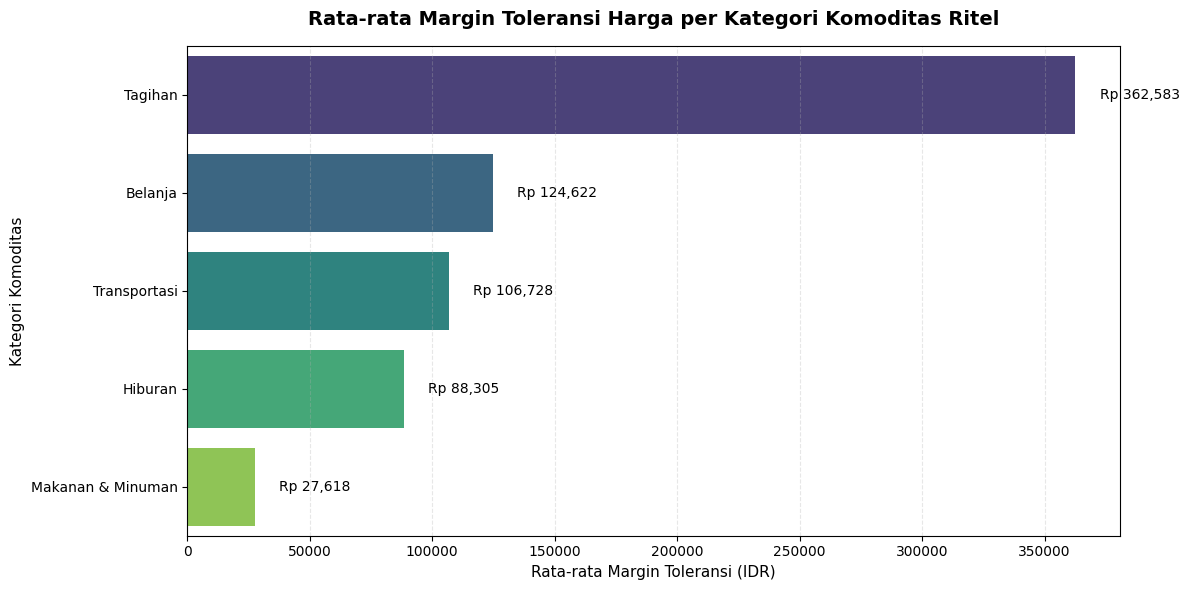


✓ Visualisasi berhasil ditampilkan

✓ TAHAP 5 SELESAI: Data Validation & EDA


In [5]:
# ============================================
# 1. PERHITUNGAN MARGIN HARGA
# ============================================
print("📊 Tahap 5a: Perhitungan margin toleransi harga...")

df_bench_cleaned['price_margin'] = df_bench_cleaned['upper_bound'] - df_bench_cleaned['lower_bound']

print("✓ Kolom 'price_margin' berhasil dihitung")
print(f"\nStatistik margin harga (IDR):")
print(df_bench_cleaned['price_margin'].describe())

# ============================================
# 2. FAILSAFE DATA INTEGRITY CHECK
# ============================================
print("\n🔍 Tahap 5b: Failsafe Data Integrity Check...")

anomali = df_bench_cleaned[df_bench_cleaned['lower_bound'] > df_bench_cleaned['upper_bound']]
print(f"✓ Baris dengan lower_bound > upper_bound: {len(anomali)}")

if len(anomali) > 0:
    print("⚠️  Anomali ditemukan:")
    print(anomali)
else:
    print("✓ Tidak ada anomali - data integritas OK")

# ============================================
# 3. GAP ANALYSIS - DETEKSI MISSING ITEMS
# ============================================
print("\n🔍 Tahap 5c: Gap Analysis - Deteksi item transaksi yang belum tercakup...")

unique_trans = df_trans[['category', 'transaction_name_clean']].drop_duplicates()
unique_trans['category'] = unique_trans['category'].str.strip().str.title()

missing_items = unique_trans[~unique_trans['transaction_name_clean'].isin(df_bench_cleaned['item_name'])]

print(f"\n📍 Jumlah item transaksi yang belum tercover: {len(missing_items)}")

if len(missing_items) > 0:
    print("\nDaftar item yang membutuhkan perhatian:")
    for idx, (_, row) in enumerate(missing_items.iterrows(), 1):
        print(f"  {idx}. {row['transaction_name_clean']} (Kategori: {row['category']})")
else:
    print("✓ Semua item transaksi sudah tercover!")

# ============================================
# 4. AGREGASI STATISTIK SEKTORAL
# ============================================
print("\n📊 Tahap 5d: Agregasi statistik per kategori...")

df_eda = df_bench_cleaned.groupby('item_category').agg({
    'price_margin': ['mean', 'min', 'max', 'std'],
    'avg_price': ['mean', 'min', 'max'],
    'item_name': 'count'
}).round(2)

df_eda.columns = ['_'.join(col).strip() for col in df_eda.columns.values]
df_eda = df_eda.rename(columns={'item_name_count': 'jumlah_item'})

print("\nStatistik per kategori:")
print(df_eda)

# ============================================
# 5. VISUALISASI MARGIN SEKTORAL
# ============================================
print("\n📊 Tahap 5e: Membuat visualisasi margin harga...")

df_vis = df_bench_cleaned.groupby('item_category')['price_margin'].mean().reset_index()
df_vis = df_vis.sort_values(by='price_margin', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=df_vis,
    x='price_margin',
    y='item_category',
    palette='viridis',
    hue='item_category',
    legend=False,
    ax=ax
)

ax.set_title('Rata-rata Margin Toleransi Harga per Kategori Komoditas Ritel', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Rata-rata Margin Toleransi (IDR)', fontsize=11)
ax.set_ylabel('Kategori Komoditas', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Tambahkan value labels di setiap bar
for i, v in enumerate(df_vis['price_margin']):
    ax.text(v + 10000, i, f'Rp {v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n✓ Visualisasi berhasil ditampilkan")

print("\n✓ TAHAP 5 SELESAI: Data Validation & EDA")


## ⏱️ TAHAP 6: FEATURE ENGINEERING
### Hitung Fitur Bisnis untuk Dashboard (price_difference, price_status, dll)

Fitur yang dihasilkan:
1. **price_difference** = amount - avg_price (selisih pengeluaran vs rata-rata)
2. **price_status** = rule-based labeling (Hemat/Normal/Ekstrem/No Data)
3. **price_percentage_of_avg** = (amount / avg_price) × 100%
4. **price_margin** = upper_bound - lower_bound (sudah dihitung di tahap sebelumnya)



In [6]:
# ============================================
# 1. MERGE TRANSAKSI DENGAN BENCHMARK
# ============================================
print("🔄 Tahap 6a: Melakukan Left Join transaksi dengan benchmark...")

df_dashboard = pd.merge(
    df_trans,
    df_bench_cleaned,
    left_on='transaction_name_clean',
    right_on='item_name',
    how='left',
    suffixes=('_trans', '_bench')
)

print(f"✓ Merge selesai: {len(df_dashboard)} baris")
print(f"  - Semua kolom dari transaksi: preserved")
print(f"  - Kolom benchmark: ditambahkan (avg_price, lower_bound, upper_bound, price_margin)")

# ============================================
# 2. HITUNG PRICE DIFFERENCE
# ============================================
print("\n🔄 Tahap 6b: Menghitung price_difference...")

kolom_harga_transaksi = 'amount'

df_dashboard['price_difference'] = df_dashboard[kolom_harga_transaksi] - df_dashboard['avg_price']

# Tampilkan contoh
print("✓ Contoh price_difference (10 baris pertama):")
print(df_dashboard[['transaction_name_clean', 'amount', 'avg_price', 'price_difference']].head(10))

# ============================================
# 3. HITUNG PRICE PERCENTAGE OF AVERAGE
# ============================================
print("\n🔄 Tahap 6c: Menghitung price_percentage_of_avg...")

df_dashboard['price_percentage_of_avg'] = (
    (df_dashboard[kolom_harga_transaksi] / df_dashboard['avg_price']) * 100
).round(2)

print("✓ Kolom 'price_percentage_of_avg' berhasil dihitung")

# ============================================
# 4. RULE-BASED PRICE STATUS LABELING
# ============================================
print("\n🔄 Tahap 6d: Rule-based labeling untuk price_status...")

# Item-item yang sifatnya fleksibel (nominal bervariasi)
item_fleksibel = [
    'Pulsa', 'Tokopedia', 'Shopee', 'Belanja Elektronik', 'Belanja Fashion',
    'Grocery Indomaret', 'Topup Gopay', 'Topup Ovo', 'Topup Saldo Dana',
    'Topup Shopeepay', 'Topup Saldo Linkaja', 'Topup Saldo Flazz E-Money'
]

# Definisikan kondisi labeling menggunakan np.select
conditions = [
    # Kondisi 1: Tidak ada data benchmark
    (df_dashboard['avg_price'].isna()),
    
    # Kondisi 2: Item fleksibel (selalu label 'Hemat')
    (df_dashboard['transaction_name_clean'].isin(item_fleksibel)),
    
    # Kondisi 3: Lebih murah dari batas bawah
    (df_dashboard[kolom_harga_transaksi] < df_dashboard['lower_bound']),
    
    # Kondisi 4: Lebih mahal dari batas atas
    (df_dashboard[kolom_harga_transaksi] > df_dashboard['upper_bound'])
]

choices = ['No Benchmark Data', 'Hemat', 'Hemat', 'Ekstrem']

df_dashboard['price_status'] = np.select(conditions, choices, default='Normal')

print("✓ Labeling selesai")
print("\nDistribusi price_status:")
print(df_dashboard['price_status'].value_counts())

# ============================================
# 5. VALIDASI FEATURE ENGINEERING
# ============================================
print("\n✓ Validasi hasil feature engineering:")

print(f"  - Kolom baru: price_difference, price_percentage_of_avg, price_status")
print(f"  - Total rows: {len(df_dashboard)}")
print(f"  - Null values di price_status: {df_dashboard['price_status'].isna().sum()}")

# Tampilkan contoh hasil lengkap
print("\nContoh hasil feature engineering (5 baris):")
print(df_dashboard[[
    'transaction_name_clean', 'amount', 'avg_price', 
    'lower_bound', 'upper_bound', 'price_difference', 
    'price_percentage_of_avg', 'price_status'
]].head())

print("\n✓ TAHAP 6 SELESAI: Feature Engineering")


🔄 Tahap 6a: Melakukan Left Join transaksi dengan benchmark...
✓ Merge selesai: 1220 baris
  - Semua kolom dari transaksi: preserved
  - Kolom benchmark: ditambahkan (avg_price, lower_bound, upper_bound, price_margin)

🔄 Tahap 6b: Menghitung price_difference...
✓ Contoh price_difference (10 baris pertama):
  transaction_name_clean    amount  avg_price  price_difference
0          Tiket Bioskop  284160.0    50000.0          234160.0
1        Spotify Premium  308000.0    55000.0          253000.0
2                Netflix  139860.0    59000.0           80860.0
3       Air Pdam Bulanan  230250.0   120000.0          110250.0
4    Listrik Pln Bulanan  498390.0   350000.0          148390.0
5     Belanja Elektronik  937950.0   500000.0          437950.0
6          Kopi Kenangan   21250.0    25000.0           -3750.0
7                   Ikea  468000.0   500000.0          -32000.0
8        Spotify Premium   74370.0    55000.0           19370.0
9                  Pulsa  519750.0    26000.0        

## ⏱️ TAHAP 7: FEATURE SELECTION
### Pilih kolom esensial untuk production output

Strategi:
1. **Identifikasi kolom yang relevan** → Hanya yang dibutuhkan dashboard UI
2. **Hapus kolom perantara** → Kolom yang digunakan hanya untuk intermediate processing
3. **Standardisasi urutan kolom** → Sesuai kebutuhan downstream
4. **Validasi tipe data** → Ensure semua kolom dengan tipe data yang benar



In [7]:
# ============================================
# 1. DEFINISIKAN KOLOM ESENSIAL UNTUK PRODUCTION
# ============================================
print("🔍 Tahap 7a: Mengidentifikasi kolom yang relevan untuk dashboard...")

# Kolom-kolom yang HARUS ada di output final
essential_columns = [
    # === Identitas Transaksi ===
    'transaction_name_clean',      # Nama item yg sudah dinormalisasi
    'amount',                        # Nominal transaksi
    'date',                          # Tanggal transaksi
    'category',                      # Kategori dari pengguna
    
    # === Referensi Benchmark ===
    'item_name',                     # Nama item dari benchmark
    'item_category',                 # Kategori dari benchmark
    'avg_price',                     # Harga rata-rata pasar
    'lower_bound',                   # Batas bawah harga
    'upper_bound',                   # Batas atas harga
    
    # === Fitur Teknis ===
    'price_margin',                  # Lebar rentang harga (upper - lower)
    'price_difference',              # Selisih pengeluaran vs rata-rata
    'price_percentage_of_avg',       # Persentase harga terhadap rata-rata
    'price_status'                   # Label status harga
]

# Filter hanya kolom yang ada
available_cols = [col for col in essential_columns if col in df_dashboard.columns]
missing_cols = [col for col in essential_columns if col not in df_dashboard.columns]

if missing_cols:
    print(f"⚠️  Kolom yang tidak tersedia: {missing_cols}")

print(f"\n✓ Kolom esensial yang ada: {len(available_cols)} dari {len(essential_columns)}")
print(f"\nDaftar kolom yang akan diexport:")
for i, col in enumerate(available_cols, 1):
    print(f"  {i:2d}. {col:30s}")

# ============================================
# 2. SELEKSI KOLOM & URUTKAN
# ============================================
print("\n🔄 Tahap 7b: Menyeleksi dan mengurutkan kolom...")

df_final = df_dashboard[available_cols].copy()

# Reset index jika diperlukan
df_final = df_final.reset_index(drop=True)

print(f"✓ Dataset final: {len(df_final)} baris × {len(df_final.columns)} kolom")

# ============================================
# 3. VALIDASI TIPE DATA
# ============================================
print("\n🔍 Tahap 7c: Validasi dan standardisasi tipe data...")

# Definisikan tipe data yang diinginkan
expected_dtypes = {
    'amount': 'float64',
    'avg_price': 'float64',
    'lower_bound': 'float64',
    'upper_bound': 'float64',
    'price_margin': 'float64',
    'price_difference': 'float64',
    'price_percentage_of_avg': 'float64',
    'price_status': 'object',
    'transaction_name_clean': 'object',
    'item_name': 'object',
    'item_category': 'object',
    'category': 'object',
    'date': 'object'
}

print("Validasi tipe data:")
for col in df_final.columns:
    actual_type = str(df_final[col].dtype)
    expected_type = expected_dtypes.get(col, 'object')
    status = '✓' if actual_type.startswith(expected_type[:3]) else '⚠️'
    print(f"  {status} {col:30s} → {actual_type}")

# Konversi tipe data jika diperlukan
for col, expected_type in expected_dtypes.items():
    if col in df_final.columns:
        if expected_type == 'float64':
            df_final[col] = pd.to_numeric(df_final[col], errors='coerce')
        elif expected_type == 'object':
            df_final[col] = df_final[col].astype('object')

print("\n✓ Standardisasi tipe data selesai")

# ============================================
# 4. CEK DATA QUALITY
# ============================================
print("\n🔍 Tahap 7d: Quality check data final...")

print(f"\nJumlah null values per kolom:")
null_summary = df_final.isnull().sum()
null_summary = null_summary[null_summary > 0]

if len(null_summary) == 0:
    print("  ✓ Tidak ada null values")
else:
    for col, count in null_summary.items():
        pct = (count / len(df_final)) * 100
        print(f"  {col:30s}: {count:5d} ({pct:5.2f}%)")

print(f"\nDuplicate rows: {df_final.duplicated().sum()}")
print(f"Total rows: {len(df_final)}")

# ============================================
# 5. TAMPILKAN PREVIEW DATA FINAL
# ============================================
print("\n📊 Preview data final (5 baris pertama):")
print(df_final.head().to_string())

print("\n📊 Info dataset final:")
print(df_final.info())

print("\n✓ TAHAP 7 SELESAI: Feature Selection")


🔍 Tahap 7a: Mengidentifikasi kolom yang relevan untuk dashboard...
⚠️  Kolom yang tidak tersedia: ['date']

✓ Kolom esensial yang ada: 12 dari 13

Daftar kolom yang akan diexport:
   1. transaction_name_clean        
   2. amount                        
   3. category                      
   4. item_name                     
   5. item_category                 
   6. avg_price                     
   7. lower_bound                   
   8. upper_bound                   
   9. price_margin                  
  10. price_difference              
  11. price_percentage_of_avg       
  12. price_status                  

🔄 Tahap 7b: Menyeleksi dan mengurutkan kolom...
✓ Dataset final: 1220 baris × 12 kolom

🔍 Tahap 7c: Validasi dan standardisasi tipe data...
Validasi tipe data:
  ⚠️ transaction_name_clean         → str
  ✓ amount                         → float64
  ⚠️ category                       → str
  ⚠️ item_name                      → str
  ⚠️ item_category                  → str
  

## ⏱️ TAHAP 8: FINAL EXPORT & PRODUCTION SUMMARY
### Export dataset final, dokumentasi, dan ringkasan proses

Output:
1. **market_benchmark_cleaned.csv** → Dataset final siap untuk dashboard UI
3. **Ringkasan proses** → Dokumentasi transformasi data



In [8]:
# ============================================
# 1. EXPORT BENCHMARK CLEANED DATA
# ============================================
print("💾 Tahap 8a: Mengexport benchmark data yang sudah di-clean...")

output_file_benchmark = base_dir / 'market_benchmark_cleaned.csv'
df_bench_cleaned.to_csv(output_file_benchmark, index=False)

print(f"✓ Benchmark data disimpan ke: {output_file_benchmark}")
print(f"  - Ukuran file: {output_file_benchmark.stat().st_size / 1024:.2f} KB")
print(f"  - Jumlah items: {len(df_bench_cleaned)}")
print(f"  - Jumlah kolom: {len(df_bench_cleaned.columns)}")

# ============================================
# 2. DOKUMENTASI TRANSFORMASI BENCHMARK
# ============================================
print("\n📋 Tahap 8b: Membuat dokumentasi transformasi benchmark...")

print("\n" + "="*80)
print("RINGKASAN PIPELINE BENCHMARK ANALYSIS")
print("="*80)

print(f"""
STATISTIK BENCHMARK:
  • Items dalam dataset original: {len(df_bench):>6d}
  • Items setelah cleaning: {len(df_bench_cleaned):>6d}
  • Kolom output: {list(df_bench_cleaned.columns)}

TAHAPAN PIPELINE:
  ✓ 1. Data Collection          - Load benchmark dataset
  ✓ 2. Data Cleaning             - Text normalization, duplikat removal
  ✓ 3. Data Integration          - Agregasi data dari multiple sources
  ✓ 4. Data Transformation       - Normalisasi kategori & item names
  ✓ 5. Data Validation & EDA     - Analisis distribusi harga
  ✓ 6. Feature Engineering       - Hitung metrics: margin, bounds
  ✓ 7. Feature Selection         - Pilih kolom esensial
  ✓ 8. Final Export              - Export market_benchmark_cleaned.csv

STATISTIK FEATURE:
  • Benchmark items dengan lower_bound: {(df_bench_cleaned['lower_bound'] > 0).sum()}
  • Benchmark items dengan upper_bound: {(df_bench_cleaned['upper_bound'] > 0).sum()}
  • Kategori unik: {df_bench_cleaned['item_category'].nunique()}
  
KATEGORI KOMODITAS:
""")

# Show category distribution
print(df_bench_cleaned['item_category'].value_counts().to_string())

print(f"""
QUALITY ASSURANCE CHECKS:
  ✓ Total rows exported: {len(df_bench_cleaned)}
  ✓ Null values (total): {df_bench_cleaned.isnull().sum().sum()}
  ✓ Duplicate rows: {df_bench_cleaned.duplicated().sum()}
  
DATA SIAP UNTUK:
  - Input ke Dashboard Visualization pipeline
  - Statistical analysis & benchmarking reports
  - Price comparison & monitoring system
""")

print("\n" + "="*80)
print("✓ BENCHMARK ANALYSIS PIPELINE SELESAI - READY FOR DASHBOARD")
print("="*80)
print(f"\n📁 Output File: {output_file_benchmark}")
print(f"🎯 Status: READY FOR PRODUCTION")
print(f"⏭️  Next: Gunakan output ini sebagai input Dashboard Visualization")



💾 Tahap 8a: Mengexport benchmark data yang sudah di-clean...
✓ Benchmark data disimpan ke: G:\Semester4\capstone-project\market_benchmark_cleaned.csv
  - Ukuran file: 17.39 KB
  - Jumlah items: 305
  - Jumlah kolom: 6

📋 Tahap 8b: Membuat dokumentasi transformasi benchmark...

RINGKASAN PIPELINE BENCHMARK ANALYSIS

STATISTIK BENCHMARK:
  • Items dalam dataset original:   2250
  • Items setelah cleaning:    305
  • Kolom output: ['item_category', 'item_name', 'avg_price', 'lower_bound', 'upper_bound', 'price_margin']

TAHAPAN PIPELINE:
  ✓ 1. Data Collection          - Load benchmark dataset
  ✓ 2. Data Cleaning             - Text normalization, duplikat removal
  ✓ 3. Data Integration          - Agregasi data dari multiple sources
  ✓ 4. Data Transformation       - Normalisasi kategori & item names
  ✓ 5. Data Validation & EDA     - Analisis distribusi harga
  ✓ 6. Feature Engineering       - Hitung metrics: margin, bounds
  ✓ 7. Feature Selection         - Pilih kolom esensial
  ✓ 8. 

## 🎁 BONUS: Analisis Tambahan & Insights

Bagian ini berisi analisis mendalam untuk business intelligence dan decision making.



In [9]:
# ============================================
# ANALISIS BONUS: Expense Anomaly Detection
# ============================================
print("🔎 ANALISIS BONUS: Expense Anomaly Detection")
print("="*70)

# Identifikasi top 10 transaksi paling 'Ekstrem'
ekstrem_df = df_final[df_final['price_status'] == 'Ekstrem'].copy()
ekstrem_df['deviation_pct'] = (
    (ekstrem_df['price_difference'] / ekstrem_df['avg_price']) * 100
).abs().round(2)

print(f"\nTotal transaksi Ekstrem: {len(ekstrem_df)}")

if len(ekstrem_df) > 0:
    top_ekstrem = ekstrem_df.nlargest(10, 'price_difference')[
        ['transaction_name_clean', 'amount', 'avg_price', 'upper_bound', 'price_difference', 'deviation_pct']
    ]
    
    print("\nTop 10 Transaksi Paling Overpriced:")
    print(top_ekstrem.to_string(index=False))

# ============================================
# ANALISIS BONUS: Category Spending Patterns
# ============================================
print("\n\n💰 ANALISIS BONUS: Category Spending Patterns")
print("="*70)

category_spending = df_final.groupby('item_category').agg({
    'amount': ['sum', 'mean', 'count'],
    'price_difference': 'mean'
}).round(0)

category_spending.columns = ['total_spending', 'avg_per_transaction', 'transaction_count', 'avg_price_diff']
category_spending = category_spending.sort_values('total_spending', ascending=False)

print("\nCategory Spending Summary:")
print(category_spending.to_string())

# ============================================
# ANALISIS BONUS: Item Popularity
# ============================================
print("\n\n📊 ANALISIS BONUS: Top 15 Items by Transaction Count")
print("="*70)

top_items = df_final['transaction_name_clean'].value_counts().head(15)
print("\n" + top_items.to_string())

print("\n✓ ANALISIS BONUS SELESAI")


🔎 ANALISIS BONUS: Expense Anomaly Detection

Total transaksi Ekstrem: 504

Top 10 Transaksi Paling Overpriced:
transaction_name_clean    amount  avg_price  upper_bound  price_difference  deviation_pct
         Tiket Pesawat 3770670.0  1000000.0    3000000.0         2770670.0         277.07
         Tiket Pesawat 3645240.0  1000000.0    3000000.0         2645240.0         264.52
         Tiket Pesawat 3637470.0  1000000.0    3000000.0         2637470.0         263.75
         Tiket Pesawat 3579750.0  1000000.0    3000000.0         2579750.0         257.98
         Tiket Pesawat 3494280.0  1000000.0    3000000.0         2494280.0         249.43
         Tiket Pesawat 3433500.0  1000000.0    3000000.0         2433500.0         243.35
         Tiket Pesawat 3229100.0  1000000.0    3000000.0         2229100.0         222.91
         Tiket Pesawat 3073590.0  1000000.0    3000000.0         2073590.0         207.36
         Tiket Pesawat 3039750.0  1000000.0    3000000.0         2039750.0     